# AnyMatch — Fine-tuned model diagnostics on the synthetic AllianceChicago eval (local)

Loads the **fine-tuned** checkpoint (`anymatch_alliance_ft_v2`) and scores the realistic, entity-first 1:9 synthetic eval set (`syntehtic_test_v2.csv`, 10k pairs), then produces a full diagnostic report:

- **4.0 Headline metrics** — accuracy, balanced accuracy, precision/recall/F1 (per-class + macro), MCC, ROC-AUC, average precision (PR-AUC), full classification report. (1:9 imbalance, so accuracy alone is misleading — lead with PR-AUC / recall.)
- **4.1 Confusion matrix + score separation** — counts & row-normalized matrix, `match_prob` histograms split by true label, ROC and precision-recall curves.
- **4.2 Threshold sweep + operating points** — precision/recall/F1 vs `match_prob` threshold; the best-F1 threshold, the threshold meeting a target precision (safe-merge), and the one meeting a target recall (high-sensitivity). Use this to pick the operating point for the real 212k run.
- **4.3 Breakdown by difficulty** — the eval's `case_type`/`corruptions_applied` provenance is degenerate here (`M-REALISTIC`=all positives, `NM-EASY`=all negatives, corruptions logged empty), so we **derive** field-agreement difficulty buckets from the `_l`/`_r` values and report recall/FP-rate per bucket. This directly tests the two fine-tune goals: (a) does matching **SSN** drive a match? (b) is the model robust to **cross-name-field shuffles** (tokens moving between first/middle/last)?
- **4.4 Error analysis** — worst false negatives (missed true matches) and false positives (wrong merges = dangerous), plus the uncertain band, with key fields and probabilities.
- **4.5 Calibration** — reliability curve + Brier score: are the `match_prob` values trustworthy as probabilities?
- **4.6 Takeaways** — an auto-generated text summary of the above.

**Where to run**: locally, from the `AnyMatch/` folder (cwd = `AnyMatch/` so relative paths resolve).

**Inference path**: this notebook scores **inline** (not via `predict_alliance.py`). The fine-tuned checkpoint ships only `tokenizer.json` (HF *fast* format), which the slow `GPT2Tokenizer` the CLI uses can't load; we load `GPT2TokenizerFast` here instead and reuse the repo's exact `df_serializer` (mode4) + `GPTDataset` + `predict`, so serialization is identical to training/serving.

**Hardware**: inference auto-selects the fastest device — **CUDA → Apple-Silicon MPS → CPU** (with an automatic CPU fallback if an op isn't MPS-supported). On an M-series Mac MPS is ~2-3x faster than CPU; pure CPU is ~270 ms/pair (≈45 min for 10k). If that's still too slow, run the inference cell (Section 3) on Colab GPU and only do Sections 4+ locally on the resulting predictions CSV — the diagnostics cells re-read `OUTPUT_CSV`, so they work regardless of where inference ran.

**A/B vs zero-shot**: set `CKPT_DIR` to `saved_models/anymatch_all9_gpt2_mode4` in Section 1, re-run, and compare the two prediction CSVs (they're named per-checkpoint).

**PHI reminder**: the synthetic corpus is non-PHI; when you swap in real patient data keep this on policy-compliant compute.

## 1. Paths — where the checkpoint lives

This notebook scores the **fine-tuned** checkpoint by default. To run locally, download the checkpoint folder from Drive (`MyDrive/AnyMatch/checkpoints/anymatch_alliance_ft_v2/`) and place it at:


That directory must contain the HuggingFace files: `model.safetensors` (or `pytorch_model.bin`), `config.json`, `vocab.json`, `merges.txt`, plus optionally `tokenizer_config.json` / `special_tokens_map.json`.

To A/B against the zero-shot base, set `CKPT_DIR = 'saved_models/anymatch_all9_gpt2_mode4'` in the next cell and re-run — output files are named per-checkpoint so they won't clobber each other.

In [1]:
import os

# === EDIT THESE IF NEEDED ===
# Point at the FINE-TUNED checkpoint (sequential FT on the synthetic corpus).
# For an A/B against the zero-shot base, set CKPT_DIR = 'saved_models/anymatch_all9_gpt2_mode4'.
CKPT_DIR    = 'saved_models/anymatch_alliance_ft_v2'
MODEL_TAG   = os.path.basename(CKPT_DIR)                     # used in output filenames / plot titles
INPUT_CSV   = 'data/synthetic/synthetic_test_v2.csv'        # realistic-distribution test (hard negatives, ~1:9)
PREPPED_CSV = 'data/synthetic/_synthetic_test_prepped.csv'  # technical->friendly, written in section 2
OUTPUT_CSV  = f'data/synthetic/synthetic_test_predictions_{MODEL_TAG}.csv'
# ============================

# Sanity check: are we in the right cwd?
assert os.path.exists('loo.py'), (
    f'Expected to run from the AnyMatch/ directory (cwd={os.getcwd()!r}). '
    "Either `cd` into AnyMatch/ before launching Jupyter, or os.chdir() here."
)

# Sanity check: checkpoint files present?
# Model weights: safetensors or the legacy bin.
has_weights = any(os.path.exists(os.path.join(CKPT_DIR, f))
                  for f in ('model.safetensors', 'pytorch_model.bin'))
# Tokenizer: either the HF *fast* file (tokenizer.json) OR the slow pair
# (vocab.json + merges.txt). The fine-tuned checkpoint here ships only
# tokenizer.json, which is why Section 3 loads GPT2TokenizerFast.
has_tok = os.path.exists(os.path.join(CKPT_DIR, 'tokenizer.json')) or all(
    os.path.exists(os.path.join(CKPT_DIR, f)) for f in ('vocab.json', 'merges.txt'))
problems = []
if not os.path.exists(os.path.join(CKPT_DIR, 'config.json')):
    problems.append('config.json')
if not has_weights:
    problems.append('model weights (model.safetensors / pytorch_model.bin)')
if not has_tok:
    problems.append('tokenizer (tokenizer.json, or vocab.json + merges.txt)')
if problems:
    raise FileNotFoundError(
        f'Missing from {CKPT_DIR}: {problems}. '
        'Download the trained checkpoint folder from Drive '
        '(MyDrive/AnyMatch/checkpoints/<ckpt>/) and place it there.'
    )
print(f'Scoring with checkpoint: {CKPT_DIR}')
print(f'Checkpoint contents:')
for f in sorted(os.listdir(CKPT_DIR)):
    p = os.path.join(CKPT_DIR, f)
    if os.path.isfile(p):
        print(f'  {f:35s} {os.path.getsize(p)/1024:>10.1f} KB')

Scoring with checkpoint: saved_models/anymatch_alliance_ft_v2
Checkpoint contents:
  config.json                                1.0 KB
  finetune_train_stat.csv                    2.3 KB
  model.safetensors                     486113.7 KB
  tokenizer.json                          3474.6 KB
  tokenizer_config.json                      0.3 KB


In [2]:
# Install deps into the current Python env. Safe to re-run.
# If you're using conda/venv, activate it before launching Jupyter.
# matplotlib is used by the diagnostic plots in Section 4 (curves/histograms).
import sys
# !pip install -q 'transformers==4.36.2' 'tokenizers<0.20' 'scikit-learn' 'pandas' 'torch' 'matplotlib'

## 2. Synthetic test data + schema alignment

We score `data/synthetic/realistic_eval_v1.csv` — the generated, entity-first realistic-distribution eval (≈1:9 match:non-match) produced by `generate_synthetic.py`. It conforms to the MDM-cleaned schema, so it exercises the model on AllianceChicago-shaped pairs.

The file's model columns use the **technical** names (`FirstNM_clean_l`, `BirthDT_clean_l`, …). The cell below renames them to the **canonical friendly schema** (`first_name`, `middle_name`, `last_name`, `suffix`, `dob`, `ssn`, `ssn4`, `sex`, `address`, `address2`, `city`, `state`, `zip`, `phone`, `email`) via `utils/alliance_schema.prep_paired_df`, and drops any `_l`/`_r` column outside that schema. This is the single source of truth shared with training and the alliance inference notebook — so the model sees three separate name fields and identical attribute names everywhere.

`label` (and provenance: `case_type`, `corruptions_applied`, `entity_id_a/b`) ride through untouched; `label` is used only for the metrics in section 4.

In [3]:
import pandas as pd
from utils.alliance_schema import id_str_dtypes, prep_paired_df

_hdr = pd.read_csv(INPUT_CSV, nrows=0).columns
raw = pd.read_csv(INPUT_CSV, dtype=id_str_dtypes(_hdr), low_memory=False)
print(f'{len(raw)} synthetic pairs, label distribution: {raw["label"].value_counts().to_dict()}')

# The generated file carries technical column names (FirstNM_clean_l, ...). Rename
# to the canonical friendly schema and drop any non-schema _l/_r columns, so the
# model sees EXACTLY the attributes it was trained on and that alliance inference
# uses. Phones_set is flattened and dob normalized inside prep_paired_df.
prepped = prep_paired_df(raw)
prepped['label'] = raw['label'].astype(int).values

# Write a reference copy, but Section 3 serializes from the IN-MEMORY `prepped`
# (not by re-reading this CSV). That matters: re-reading would let pandas re-infer
# float64 for zip/ssn4/phone (-> "60640.0", "1234.0"), which diverges from how
# finetune_alliance.py serialized during training (string "60640"/"1234"). Scoring
# off the in-memory frame keeps the mode4 prompt byte-identical to training.
prepped.to_csv(PREPPED_CSV, index=False)
print(f'Wrote prepped pairs ({len(prepped.columns)} cols) -> {PREPPED_CSV}')
prepped.head()

10000 synthetic pairs, label distribution: {0: 8000, 1: 2000}
Wrote prepped pairs (37 cols) -> data/synthetic/_synthetic_test_prepped.csv


,PATID_A,PATID_B,label,case_type,corruptions_applied,entity_id_a,entity_id_b,first_name_l,middle_name_l,last_name_l,...,ssn_r,ssn4_r,sex_r,address_r,address2_r,city_r,state_r,zip_r,phone_r,email_r
0,S000091677,S000091678,0,NM-HARD-LAST4,[],E000073746,E000073747,JUAN,NaN,HRENANDEZ,...,<NA>,6939,FEMALE,3682 FULLERTON ST,NaN,CHICAGO,IL,60653,2245155983 7083676560 8475843613,NaN
1,S000091275,S000091276,0,NM-HARD-LASTNAME+PHONE,[],E000073344,E000073345,PHUONG,NaN,GONZALEZ,...,<NA>,0802,FEMALE,10229 DEVON PL,2ND 2D,CHICAGO,IL,60615,2244796118 3127697443 4645589218 6303678808,andrew.reyes@gmail.com
2,S000082493,S000082494,1,M-BULK-HARD,"[""drop_middle"", ""address_move"", ""phone_replace...",E000065316,E000065316,NOA,G,DELGADO,...,<NA>,<NA>,FEMALE,3757 ELSTON AVE,APT 2B,CHICAGO,IL,60612,3122480740 3312414896,ndelgado@gmail.com
3,S000087681,S000087682,0,NM-IDF-01,[],E000069750,E000069751,DELORES,NaN,WILLIAMS,...,<NA>,<NA>,NaN,4458 HAMLIN AVE,NaN,CHICAGO,IL,60625,3313526616 8475880123,rrodriguez@gmail.com
4,S000096683,S000096684,0,NM-HARD-ADDR+DOB+PHONE,[],E000078752,E000078753,THOMAS,NaN,GOMEZ,...,<NA>,7805,NaN,13575 OHIO AVE,NaN,CHICAGO,IL,60632,2407144202 3015240616 7739002085,NaN


## 3. Run inference (inline)

Scores every pair **in-process**, reusing the repo's own serialization and prediction code so the prompt is byte-identical to training/serving:

- `df_serializer(df, 'mode4')` → `Given the attributes of two records, are they the same? Record A is first_name: <v>, ... . Record B is ... .`
- `GPTDataset` tokenizes (we assert no row is dropped by the length filter), and a small inline scorer returns `pred` (argmax 0/1) and `match_prob` = `softmax(logits)[:, 1]`. It mirrors `utils.train_eval.predict` but selects the device **CUDA → MPS → CPU** (the shared `predict()` only checks CUDA, so it would never use Apple-Silicon MPS).

**Tokenizer note**: the fine-tuned checkpoint ships only `tokenizer.json` (HF *fast* format). The slow `GPT2Tokenizer` used by `predict_alliance.py` can't load it (no `vocab.json`/`merges.txt`), and `GPT2TokenizerFast` can fail too if the local `tokenizers` library is older than the one that wrote the file (`data did not match any variant ... ModelWrapper`). The cell therefore tries the checkpoint's fast tokenizer and **falls back to the base `gpt2` BPE** — fine-tuning never changes GPT-2's vocab, so token IDs are identical to training either way. Output is written to `OUTPUT_CSV` with `pred` / `match_prob` appended and all provenance columns preserved.

In [4]:
import os, time
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import GPT2Tokenizer, GPT2TokenizerFast, GPT2ForSequenceClassification

from utils.data_utils import df_serializer
from data import GPTDataset

# Let any op MPS doesn't implement fall back to CPU instead of erroring.
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

BATCH_SIZE    = 32
MAX_LEN       = 1024       # GPT-2 context cap; mode4 patient prompts are ~150-250 tok, so nothing is filtered
TOKENIZER_SRC = 'gpt2'     # GPT-2 BPE is fixed; fine-tuning never changes the vocab

# Use the IN-MEMORY `prepped` from Section 2 (not a CSV re-read) so the prompt
# matches training exactly — see the note in that cell. If you're scoring on Colab,
# just run Section 2 then this cell in the same kernel.
assert 'prepped' in globals(), 'Run Section 2 (the prep cell) first to build `prepped`.'
print(f'Serializing {len(prepped)} prepped pairs (in memory)')

# df_serializer needs a `label` column (it projects to [text, label]).
serial_src = prepped.copy()
if 'label' not in serial_src.columns:
    serial_src['label'] = 0
serialized = df_serializer(serial_src.copy(), 'mode4')
print('Example serialized prompt:\n', serialized['text'].iloc[0][:400], '...\n')

# Tokenizer: try the checkpoint's own tokenizer.json (fast), but fall back to the
# base gpt2 BPE if the local `tokenizers` lib is older than the one that wrote it
# ("data did not match any variant ... ModelWrapper"). The vocab is identical, so
# token IDs match training either way.
try:
    tokenizer = GPT2TokenizerFast.from_pretrained(CKPT_DIR)
    print('Tokenizer: fast, from checkpoint')
except Exception as e:
    print(f'[info] fast tokenizer from checkpoint failed ({type(e).__name__}); '
          f'falling back to base {TOKENIZER_SRC!r} tokenizer (identical BPE).')
    tokenizer = GPT2Tokenizer.from_pretrained(TOKENIZER_SRC)

model = GPT2ForSequenceClassification.from_pretrained(CKPT_DIR)
model.config.pad_token_id = model.config.eos_token_id

dataset = GPTDataset(tokenizer, serialized, max_len=MAX_LEN)
assert len(dataset) == len(prepped), (
    f'{len(prepped) - len(dataset)} row(s) dropped by the length filter — raise MAX_LEN.')

def pick_device():
    """Prefer CUDA, then Apple-Silicon MPS, else CPU."""
    if torch.cuda.is_available():
        return torch.device('cuda')
    mps = getattr(torch.backends, 'mps', None)
    if mps is not None and mps.is_available() and mps.is_built():
        return torch.device('mps')
    return torch.device('cpu')


@torch.no_grad()
def score(model, dataset, batch_size, device):
    """Inline equivalent of utils.train_eval.predict, but device-selectable
    (the shared predict() only checks CUDA). Returns (preds, probs)."""
    dl = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=dataset.collate_fn)
    model.to(device); model.eval()
    preds, probs = [], []
    for batch in dl:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits.detach().float()
        probs += torch.softmax(logits, dim=-1)[:, 1].cpu().numpy().tolist()
        preds += logits.argmax(dim=-1).cpu().numpy().flatten().tolist()
    return preds, probs


device = pick_device()
print(f'Scoring {len(dataset)} pairs on {device.type.upper()} (batch={BATCH_SIZE}) ...')
_t0 = time.perf_counter()
try:
    preds, probs = score(model, dataset, BATCH_SIZE, device)
except (RuntimeError, NotImplementedError) as e:
    if device.type == 'mps':
        print(f'[warn] MPS scoring failed ({type(e).__name__}: {str(e)[:120]}); retrying on CPU.')
        device = torch.device('cpu')
        preds, probs = score(model, dataset, BATCH_SIZE, device)
    else:
        raise
_total_s = time.perf_counter() - _t0

out = prepped.copy()
out['pred'] = preds
out['match_prob'] = probs
out.to_csv(OUTPUT_CSV, index=False)

print(f'\nWrote {len(out)} predictions -> {OUTPUT_CSV}')
print(f'Total inference time : {_total_s:.2f} s')
print(f'Time per pair        : {_total_s / len(out) * 1000:.1f} ms')
print(f'Predicted-match rate : {out["pred"].mean()*100:.1f}%  (eval prior = {out["label"].mean()*100:.1f}% positives)')

/opt/anaconda3/envs/llm_env/lib/python3.11/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/anaconda3/envs/llm_env/lib/python3.11/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Serializing 10000 prepped pairs (in memory)
Example serialized prompt:
 Given the attributes of two records, are they the same? Record A is first_name: JUAN, middle_name: N/A, last_name: HRENANDEZ, suffix: N/A, dob: 1988-04-11, ssn: 315126939, ssn4: 6939, sex: N/A, address: 13017 WINCHESTER DR, address2: APT 9, city: LEXINGTON, state: KY, zip: 40505, phone: 6064772733 6068220231, email: N/A. Record B is first_name: ISABELA, middle_name: N/A, last_name: GOMEZ, suffix:  ...

[info] fast tokenizer from checkpoint failed (Exception); falling back to base 'gpt2' tokenizer (identical BPE).


/opt/anaconda3/envs/llm_env/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


0 out of 10000 data samples are filtered.
Scoring 10000 pairs on MPS (batch=32) ...

Wrote 10000 predictions -> data/synthetic/synthetic_test_predictions_anymatch_alliance_ft_v2.csv
Total inference time : 338.88 s
Time per pair        : 33.9 ms
Predicted-match rate : 20.4%  (eval prior = 20.0% positives)


## 4. Diagnostics

The synthetic eval carries ground-truth `label` plus provenance (`case_type`, `corruptions_applied`, `entity_id_a/b`). Everything below keys off `OUTPUT_CSV`, so you can run inference on Colab and do this part locally on the resulting CSV. The next cell loads predictions once into `out` and defines shared helpers (`y_true`, `y_prob`, `y_pred`, a matplotlib guard) that the rest of Section 4 reuses.

### 4.0 Load predictions + headline metrics

With a 1:9 prior, **accuracy is misleading** (a constant "no-match" scores 90%). Read **PR-AUC**, **recall**, and **MCC** first; ROC-AUC is reported but is optimistic under imbalance.

In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_score, recall_score, matthews_corrcoef,
                             roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix)

# matplotlib guard: plots are nice-to-have; degrade to text if it's not installed.
try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False
    print('[warn] matplotlib not installed -> plots skipped. '
          "Run the install cell with 'matplotlib' uncommented for the curves.")

# --- Load predictions once; everything in Section 4 reuses these. ---
# Force the numeric-ID columns back to string so display/agreement don't suffer the
# float trap ("60640.0", "1234.0") on re-read.
_ohdr = pd.read_csv(OUTPUT_CSV, nrows=0).columns
_ostr = {c: 'string' for base in ['zip', 'ssn', 'ssn4', 'phone']
         for c in (f'{base}_l', f'{base}_r') if c in _ohdr}
out = pd.read_csv(OUTPUT_CSV, dtype=_ostr, low_memory=False)
assert {'label', 'pred', 'match_prob'} <= set(out.columns), 'predictions CSV missing required columns'

y_true = out['label'].astype(int).to_numpy()
y_pred = out['pred'].astype(int).to_numpy()
y_prob = out['match_prob'].astype(float).to_numpy()
N, P, Ncount = len(out), int(y_true.sum()), int((y_true == 0).sum())
print(f'{N} pairs scored  |  positives (true matches) = {P}  |  negatives = {Ncount}  '
      f'|  prior = {P / N * 100:.1f}% positive\n')

# --- Headline metrics (threshold = 0.5, i.e. the model's argmax `pred`) ---
hl = {
    'accuracy'          : accuracy_score(y_true, y_pred),
    'balanced_accuracy' : balanced_accuracy_score(y_true, y_pred),
    'precision (match)' : precision_score(y_true, y_pred, zero_division=0),
    'recall (match)'    : recall_score(y_true, y_pred, zero_division=0),
    'f1 (match)'        : f1_score(y_true, y_pred, zero_division=0),
    'f1 (macro)'        : f1_score(y_true, y_pred, average='macro', zero_division=0),
    'MCC'               : matthews_corrcoef(y_true, y_pred),
    'ROC-AUC'           : roc_auc_score(y_true, y_prob),
    'PR-AUC (avg prec)' : average_precision_score(y_true, y_prob),
}
print('=== Headline metrics (pred @ argmax / 0.5 threshold) ===')
for k, v in hl.items():
    print(f'  {k:20s} : {v:.4f}')

print('\n=== Classification report ===')
print(classification_report(y_true, y_pred, target_names=['no-match (0)', 'match (1)'],
                            digits=3, zero_division=0))

10000 pairs scored  |  positives (true matches) = 2000  |  negatives = 8000  |  prior = 20.0% positive

=== Headline metrics (pred @ argmax / 0.5 threshold) ===
  accuracy             : 0.9953
  balanced_accuracy    : 0.9969
  precision (match)    : 0.9775
  recall (match)       : 0.9995
  f1 (match)           : 0.9884
  f1 (macro)           : 0.9927
  MCC                  : 0.9855
  ROC-AUC              : 0.9998
  PR-AUC (avg prec)    : 0.9990

=== Classification report ===
              precision    recall  f1-score   support

no-match (0)      1.000     0.994     0.997      8000
   match (1)      0.978     1.000     0.988      2000

    accuracy                          0.995     10000
   macro avg      0.989     0.997     0.993     10000
weighted avg      0.995     0.995     0.995     10000



### 4.1 Confusion matrix & score separation

The confusion matrix (counts + row-normalized) shows the four outcomes; for entity resolution the asymmetry matters — a **false positive is a wrong merge** (two different patients collapsed) while a **false negative is a missed link** (duplicate left in the data). The `match_prob` histograms (split by true label) show how separable the two classes are, and the ROC / precision-recall curves summarize performance across all thresholds.

=== Confusion matrix (counts) ===
               pred no-match  pred match
true no-match           7954          46
true match                 1        1999

=== Confusion matrix (row-normalized) ===
               pred no-match  pred match
true no-match         0.9942      0.0058
true match            0.0005      0.9995

TP=1999  FP=46  FN=1  TN=7954
False merges (FP) = 46  |  Missed links (FN) = 1


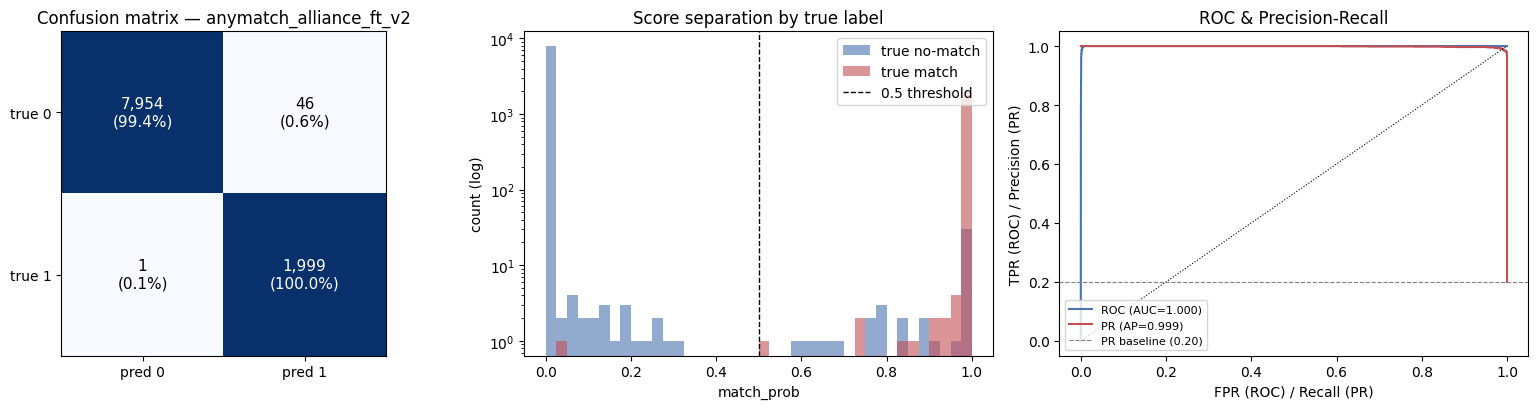

In [6]:
from sklearn.metrics import roc_curve, precision_recall_curve

# --- Confusion matrix (counts + row-normalized) ---
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
cm_df = pd.DataFrame(cm, index=['true no-match', 'true match'],
                     columns=['pred no-match', 'pred match'])
cm_norm = cm / cm.sum(axis=1, keepdims=True)
cm_norm_df = pd.DataFrame(cm_norm, index=['true no-match', 'true match'],
                          columns=['pred no-match', 'pred match'])
print('=== Confusion matrix (counts) ===')
print(cm_df)
print('\n=== Confusion matrix (row-normalized) ===')
print(cm_norm_df.round(4))
print(f'\nTP={tp}  FP={fp}  FN={fn}  TN={tn}')
print(f'False merges (FP) = {fp}  |  Missed links (FN) = {fn}')

if HAVE_MPL:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

    # (1) confusion matrix heatmap (row-normalized, annotated with counts)
    ax = axes[0]
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['pred 0', 'pred 1'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['true 0', 'true 1'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}\n({cm_norm[i, j]*100:.1f}%)',
                    ha='center', va='center',
                    color='white' if cm_norm[i, j] > 0.5 else 'black', fontsize=11)
    ax.set_title(f'Confusion matrix — {MODEL_TAG}')

    # (2) match_prob histograms by true label
    ax = axes[1]
    bins = np.linspace(0, 1, 41)
    ax.hist(y_prob[y_true == 0], bins=bins, alpha=0.6, label='true no-match', color='#4C72B0')
    ax.hist(y_prob[y_true == 1], bins=bins, alpha=0.6, label='true match', color='#C44E52')
    ax.axvline(0.5, color='k', ls='--', lw=1, label='0.5 threshold')
    ax.set_yscale('log')
    ax.set_xlabel('match_prob'); ax.set_ylabel('count (log)')
    ax.set_title('Score separation by true label'); ax.legend()

    # (3) ROC + PR curves
    ax = axes[2]
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ax.plot(fpr, tpr, label=f'ROC (AUC={roc_auc_score(y_true, y_prob):.3f})', color='#4C72B0')
    ax.plot(rec, prec, label=f'PR (AP={average_precision_score(y_true, y_prob):.3f})', color='#C44E52')
    ax.plot([0, 1], [0, 1], 'k:', lw=0.8)
    ax.axhline(P / N, color='gray', ls='--', lw=0.8, label=f'PR baseline ({P/N:.2f})')
    ax.set_xlabel('FPR (ROC) / Recall (PR)'); ax.set_ylabel('TPR (ROC) / Precision (PR)')
    ax.set_title('ROC & Precision-Recall'); ax.legend(loc='lower left', fontsize=8)

    plt.tight_layout(); plt.show()

### 4.2 Threshold sweep & operating points

`pred` uses the model's 0.5 argmax, but the right cut depends on the cost of a wrong merge vs. a missed link. The sweep shows precision/recall/F1 across thresholds; we then surface three candidate operating points to carry into the real 212k run: **best-F1**, a **safe-merge** point (highest recall subject to precision ≥ target), and a **high-sensitivity** point (highest precision subject to recall ≥ target).

=== Threshold sweep (match class) ===
 threshold  precision  recall     f1   TP  FP  FN
      0.05     0.9676  0.9995 0.9833 1999  67   1
      0.10     0.9704  0.9995 0.9847 1999  61   1
      0.15     0.9727  0.9995 0.9859 1999  56   1
      0.20     0.9746  0.9995 0.9869 1999  52   1
      0.25     0.9756  0.9995 0.9874 1999  50   1
      0.30     0.9770  0.9995 0.9881 1999  47   1
      0.35     0.9775  0.9995 0.9884 1999  46   1
      0.40     0.9775  0.9995 0.9884 1999  46   1
      0.45     0.9775  0.9995 0.9884 1999  46   1
      0.50     0.9775  0.9995 0.9884 1999  46   1
      0.55     0.9775  0.9990 0.9881 1998  46   2
      0.60     0.9780  0.9990 0.9884 1998  45   2
      0.65     0.9789  0.9990 0.9889 1998  43   2
      0.70     0.9799  0.9990 0.9894 1998  41   2
      0.75     0.9799  0.9980 0.9889 1996  41   4
      0.80     0.9823  0.9980 0.9901 1996  36   4
      0.85     0.9832  0.9975 0.9903 1995  34   5
      0.90     0.9842  0.9970 0.9906 1994  32   6
      0.95  

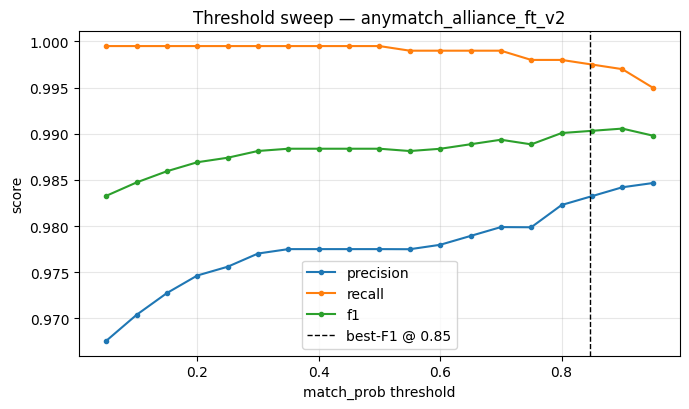

In [7]:
# --- Threshold sweep (match class) ---
ths = np.round(np.arange(0.05, 1.00, 0.05), 2)
rows = []
for t in ths:
    p = (y_prob >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_true, p, zero_division=0),
        'recall'   : recall_score(y_true, p, zero_division=0),
        'f1'       : f1_score(y_true, p, zero_division=0),
        'TP': int(((p == 1) & (y_true == 1)).sum()),
        'FP': int(((p == 1) & (y_true == 0)).sum()),
        'FN': int(((p == 0) & (y_true == 1)).sum()),
    })
sweep = pd.DataFrame(rows)
print('=== Threshold sweep (match class) ===')
print(sweep.round(4).to_string(index=False))

# --- Operating points from the full PR curve ---
prec_c, rec_c, pr_th = precision_recall_curve(y_true, y_prob)
prec_c, rec_c = prec_c[:-1], rec_c[:-1]   # align with thresholds (curve has n+1 points)
f1_c = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-12)


def _metrics_at(t):
    p = (y_prob >= t).astype(int)
    return dict(threshold=float(t),
                precision=precision_score(y_true, p, zero_division=0),
                recall=recall_score(y_true, p, zero_division=0),
                f1=f1_score(y_true, p, zero_division=0),
                FP=int(((p == 1) & (y_true == 0)).sum()),
                FN=int(((p == 0) & (y_true == 1)).sum()))


def _target(metric_arr, target, maximize_arr):
    ok = metric_arr >= target
    if not ok.any():
        return None
    idx = np.where(ok)[0]
    return float(pr_th[idx[np.argmax(maximize_arr[idx])]])


op = {}
op['best_F1']            = float(pr_th[int(np.nanargmax(f1_c))]) if len(pr_th) else 0.5
op['precision>=0.95']    = _target(prec_c, 0.95, rec_c)   # safe-merge: max recall s.t. precision>=0.95
op['precision>=0.99']    = _target(prec_c, 0.99, rec_c)
op['recall>=0.95']       = _target(rec_c, 0.95, prec_c)   # high-sensitivity: max precision s.t. recall>=0.95
op['recall>=0.99']       = _target(rec_c, 0.99, prec_c)

print('\n=== Candidate operating points ===')
op_rows = [{'point': 'default (0.5)', **_metrics_at(0.5)}]
for name, t in op.items():
    if t is None:
        print(f'  [{name}] not achievable on this eval')
        continue
    op_rows.append({'point': name, **_metrics_at(t)})
op_df = pd.DataFrame(op_rows)
print(op_df.round(4).to_string(index=False))

if HAVE_MPL:
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(sweep['threshold'], sweep['precision'], label='precision', marker='.')
    ax.plot(sweep['threshold'], sweep['recall'],    label='recall',    marker='.')
    ax.plot(sweep['threshold'], sweep['f1'],        label='f1',        marker='.')
    if op['best_F1'] is not None:
        ax.axvline(op['best_F1'], color='k', ls='--', lw=1, label=f"best-F1 @ {op['best_F1']:.2f}")
    ax.set_xlabel('match_prob threshold'); ax.set_ylabel('score')
    ax.set_title(f'Threshold sweep — {MODEL_TAG}'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

### 4.3 Breakdown by difficulty (derived field-agreement buckets)

The eval's `case_type` is degenerate (`M-REALISTIC` = the 1000 positives, `NM-*` = the 9000 negatives) and `corruptions_applied` is logged empty, so a raw provenance breakdown is uninformative. Instead we **derive** difficulty buckets from the actual `_l`/`_r` field values and measure:

- **Per-field agreement → recall (positives):** for true matches, does recall hold up when `last_name` / `dob` / `first_name` *disagree* (i.e., the pair was corrupted)? Those are the cases the model must still link.
- **SSN-decisiveness (fine-tune goal a):** recall on positives whose full **SSN** (or last-4) agrees should be ≈1; we also check the FP rate on negatives that *coincidentally* share last-4.
- **Cross-name-field shuffle (fine-tune goal b):** positives where the per-field names disagree but the combined first+middle+last **token multiset matches** — tokens moved between fields. Robust recall here is exactly what the fine-tune was meant to buy.
- **Hard negatives:** FP rate on negatives that share a strong signal (`dob`, `last_name`, or `ssn4`) — the look-alikes blocking surfaces.

In [8]:
# ---------- helpers ----------
def _norm(s):
    return '' if pd.isna(s) else str(s).strip().upper()


def _col(name, side):
    c = f'{name}_{side}'
    return out[c].map(_norm) if c in out.columns else pd.Series([''] * len(out), index=out.index)


def both_eq(name):
    l, r = _col(name, 'l'), _col(name, 'r')
    return (l != '') & (r != '') & (l == r)


def both_diff(name):
    l, r = _col(name, 'l'), _col(name, 'r')
    return (l != '') & (r != '') & (l != r)


def name_token_set(side):
    parts = [_col('first_name', side), _col('middle_name', side), _col('last_name', side)]
    out_sets = []
    for vals in zip(*[p.tolist() for p in parts]):
        toks = frozenset(t for v in vals for t in v.split() if t)
        out_sets.append(toks)
    return pd.Series(out_sets, index=out.index)


def subset_stats(mask):
    m = np.asarray(mask)
    n = int(m.sum())
    if n == 0:
        return dict(n=0, n_pos=0, n_neg=0, recall=np.nan, fp_rate=np.nan, mean_prob=np.nan)
    yt, yp, pr = y_true[m], y_pred[m], y_prob[m]
    npos, nneg = int((yt == 1).sum()), int((yt == 0).sum())
    return dict(
        n=n, n_pos=npos, n_neg=nneg,
        recall=float((yp[yt == 1] == 1).mean()) if npos else np.nan,
        fp_rate=float((yp[yt == 0] == 1).mean()) if nneg else np.nan,
        mean_prob=float(pr.mean()),
    )


pos = y_true == 1   # boolean over rows

# ---------- (a) raw case_type table (degenerate but requested) ----------
if 'case_type' in out.columns:
    ct = (out.assign(correct=(y_true == y_pred))
             .groupby('case_type')
             .agg(n=('label', 'size'), n_pos=('label', 'sum'),
                  accuracy=('correct', 'mean'), mean_prob=('match_prob', 'mean'))
             .sort_values('n', ascending=False))
    print('=== case_type breakdown ===')
    print(ct.round(4).to_string())

# ---------- (b) per-field agreement -> recall on positives ----------
print('\n=== Recall on true matches, split by per-field agreement ===')
field_rows = []
for f in ['ssn', 'ssn4', 'dob', 'last_name', 'first_name', 'middle_name', 'zip', 'phone', 'address', 'sex']:
    if f'{f}_l' not in out.columns:
        continue
    eqm = both_eq(f).to_numpy()
    dfm = both_diff(f).to_numpy()
    field_rows.append({'field': f,
                       'pos_agree_n': int((pos & eqm).sum()),
                       'recall_when_agree': subset_stats(pos & eqm)['recall'],
                       'pos_disagree_n': int((pos & dfm).sum()),
                       'recall_when_disagree': subset_stats(pos & dfm)['recall']})
print(pd.DataFrame(field_rows).round(4).to_string(index=False))

# ---------- (c) SSN-decisiveness (fine-tune goal a) ----------
print('\n=== SSN decisiveness ===')
ssn_any_eq = (both_eq('ssn') | both_eq('ssn4')).to_numpy()
print('Positives WITH matching SSN/ssn4 :', subset_stats(pos & ssn_any_eq))
print('Positives WITHOUT matching SSN   :', subset_stats(pos & ~ssn_any_eq))
print('Negatives sharing ssn4 (look-alike):', subset_stats((~pos) & both_eq('ssn4').to_numpy()))

# ---------- (d) cross-name-field shuffle (fine-tune goal b) ----------
print('\n=== Cross-name-field token shuffle ===')
nset_l, nset_r = name_token_set('l'), name_token_set('r')
set_eq = np.array([(a == b) and len(a) > 0 for a, b in zip(nset_l, nset_r)])
fieldwise_eq = (both_eq('first_name') & both_eq('last_name')).to_numpy()
shuffled = set_eq & ~fieldwise_eq          # same tokens, but they sit in different fields
print('Positives, names aligned field-by-field :', subset_stats(pos & fieldwise_eq))
print('Positives, tokens SHUFFLED across fields :', subset_stats(pos & shuffled))

# ---------- (e) hard negatives ----------
print('\n=== Hard negatives (false-merge risk) ===')
for sig in ['dob', 'last_name', 'ssn4']:
    if f'{sig}_l' in out.columns:
        print(f'Negatives sharing {sig:10s}:', subset_stats((~pos) & both_eq(sig).to_numpy()))

=== case_type breakdown ===
                                           n  n_pos  accuracy  mean_prob
case_type                                                               
M-BULK-HARD                             1040   1040    0.9990     0.9971
NM-HARD-ADDR                             738      0    1.0000     0.0000
NM-HARD-LASTNAME                         720      0    1.0000     0.0000
NM-HARD-DOB                              717      0    0.9958     0.0036
NM-HARD-PHONE                            699      0    1.0000     0.0002
NM-HARD-DOB+LASTNAME                     248      0    0.9919     0.0087
NM-HARD-ADDR+LASTNAME                    226      0    1.0000     0.0000
NM-HARD-LASTNAME+PHONE                   221      0    1.0000     0.0000
NM-HARD-ADDR+DOB                         217      0    0.9954     0.0046
NM-HARD-ADDR+PHONE                       201      0    1.0000     0.0006
M-BULK-L4                                195    195    1.0000     0.9990
NM-HARD-DOB+PHONE      

### 4.4 Error analysis

The concrete mistakes. **False negatives** (true matches the model missed, lowest `match_prob` first) reveal which corruptions defeat it; **false positives** (non-matches it would merge, highest `match_prob` first) are the dangerous wrong-merges to inspect before trusting the model on real data. The **uncertain band** (`match_prob` near 0.5) shows where the model is least confident.

In [9]:
_view = ['match_prob', 'label', 'pred',
         'first_name_l', 'first_name_r', 'middle_name_l', 'middle_name_r',
         'last_name_l', 'last_name_r', 'dob_l', 'dob_r',
         'ssn4_l', 'ssn4_r', 'zip_l', 'zip_r']
_view = [c for c in _view if c in out.columns]
TOPK = 20


def _show(df_, title):
    print(f'\n=== {title}  (showing up to {TOPK} of {len(df_)}) ===')
    disp = df_[_view].head(TOPK).copy()
    disp['match_prob'] = disp['match_prob'].round(3)
    try:
        display(disp)
    except NameError:
        print(disp.to_string(index=False))


fn = out[(out['label'] == 1) & (out['pred'] == 0)].sort_values('match_prob')              # missed matches
fp = out[(out['label'] == 0) & (out['pred'] == 1)].sort_values('match_prob', ascending=False)  # wrong merges
unc = out[(out['match_prob'] > 0.4) & (out['match_prob'] < 0.6)].sort_values('match_prob')

print(f'False negatives (missed matches): {len(fn)}   |   '
      f'False positives (wrong merges): {len(fp)}   |   '
      f'Uncertain 0.4-0.6: {len(unc)}')
_show(fn, 'Worst FALSE NEGATIVES (lowest prob true matches)')
_show(fp, 'Worst FALSE POSITIVES (highest prob non-matches)')
_show(unc, 'Most UNCERTAIN pairs (prob near 0.5)')

False negatives (missed matches): 1   |   False positives (wrong merges): 46   |   Uncertain 0.4-0.6: 2

=== Worst FALSE NEGATIVES (lowest prob true matches)  (showing up to 20 of 1) ===


,match_prob,label,pred,first_name_l,first_name_r,middle_name_l,middle_name_r,last_name_l,last_name_r,dob_l,dob_r,ssn4_l,ssn4_r,zip_l,zip_r
6883,0.044,1,0,ASHLEY,ASLEY,H,NaN,MOORE,MOORE,1964-01-21,1964-01-21,<NA>,5072,60636,60636



=== Worst FALSE POSITIVES (highest prob non-matches)  (showing up to 20 of 46) ===


,match_prob,label,pred,first_name_l,first_name_r,middle_name_l,middle_name_r,last_name_l,last_name_r,dob_l,dob_r,ssn4_l,ssn4_r,zip_l,zip_r
7560,1.000,0,1,ANTHONY,ANTHONY,NaN,NaN,JIMENEZ,SANCHEZ,2009-01-28,2009-01-28,0117,0117,60645,60640
2488,1.000,0,1,JESSICA,JESSICA,O,NaN,THOMAS,GONZALEZ,1975-03-16,1975-03-16,0591,0591,60636,60653
8793,1.000,0,1,RICHARD,RICHARD,NaN,NaN,BROWN,BROWN,1992-07-01,1992-07-02,<NA>,<NA>,60618,60626
542,1.000,0,1,JOHN,JOHN,NaN,NaN,RODRIGUEZ,RODRIGUEZ,1966-05-24,1966-05-24,<NA>,<NA>,60625,60641
123,1.000,0,1,CARLOS,CARLOS,T,NaN,SCHNEIDER,SCHNEIDER,1981-12-22,1981-12-21,<NA>,<NA>,60640,60657
4160,0.999,0,1,MARIA,MARIA,D,NaN,TORRES,KELLY,1992-03-14,1992-03-14,9593,<NA>,60639,60620
5782,0.999,0,1,CARLOS,CARLOS,NaN,NaN,RIVERA,RIVERA,1966-03-05,1966-03-05,<NA>,<NA>,60618,60657
3204,0.999,0,1,JENNIFER,JENNIFER,NaN,NaN,BRWN,BRWN,1967-09-11,1967-09-11,<NA>,<NA>,60649,60610
1400,0.999,0,1,KIMBERLY,KIMBERLY,NaN,NaN,JACKSON,JACKSON,1949-11-27,1956-11-27,<NA>,<NA>,60647,60647
9240,0.998,0,1,RENATA,RENATA,K,NaN,GARCIA,GARCIA,2009-10-11,2009-10-09,<NA>,<NA>,60629,60625



=== Most UNCERTAIN pairs (prob near 0.5)  (showing up to 20 of 2) ===


,match_prob,label,pred,first_name_l,first_name_r,middle_name_l,middle_name_r,last_name_l,last_name_r,dob_l,dob_r,ssn4_l,ssn4_r,zip_l,zip_r
3868,0.513,1,1,GERALD,ERALD,NaN,NaN,WILSON,IWLSON,2003-06-28,2001-06-28,9021,<NA>,60615,60639
8883,0.585,0,1,JOHN,JOHN,R,NaN,GOMEZ,GOMEZ,1965-07-02,1965-07-01,2875,<NA>,60649,60641


### 4.5 Calibration

Are the `match_prob` values trustworthy as probabilities? The reliability curve bins predictions and plots mean predicted probability vs. observed match rate; a well-calibrated model tracks the diagonal. The **Brier score** (lower = better) summarizes calibration + sharpness. GPT-2 classifiers are often over-confident, so expect mass piled near 0 and 1 — relevant if you plan to threshold on `match_prob` for the real run.

Brier score = 0.0041  (0 = perfect, lower is better)

=== Reliability table ===
      bin    n  mean_pred_prob  observed_match_rate
[0.0,0.1) 7940          0.0001               0.0001
[0.1,0.2)    9          0.1508               0.0000
[0.2,0.3)    5          0.2527               0.0000
[0.3,0.4)    1          0.3236               0.0000
[0.5,0.6)    2          0.5489               0.5000
[0.6,0.7)    4          0.6553               0.0000
[0.7,0.8)    7          0.7663               0.2857
[0.8,0.9)    6          0.8564               0.3333
[0.9,1.0) 2026          0.9993               0.9842


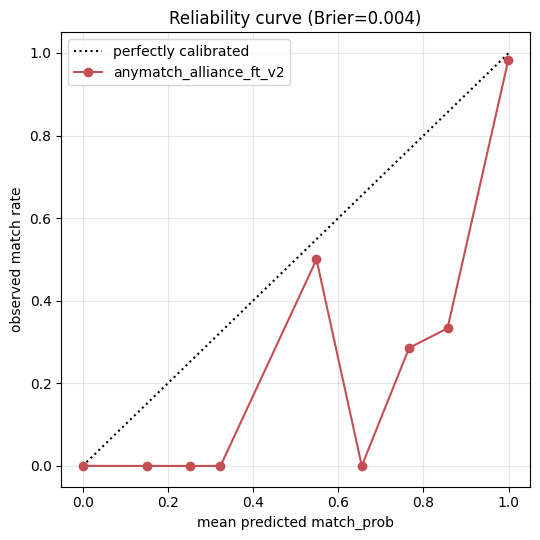

In [10]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_true, y_prob)
print(f'Brier score = {brier:.4f}  (0 = perfect, lower is better)')

frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')

# Per-bin table.
edges = np.linspace(0, 1, 11)
bin_idx = np.clip(np.digitize(y_prob, edges) - 1, 0, 9)
cal_rows = []
for b in range(10):
    m = bin_idx == b
    if m.sum() == 0:
        continue
    cal_rows.append({'bin': f'[{edges[b]:.1f},{edges[b+1]:.1f})',
                     'n': int(m.sum()),
                     'mean_pred_prob': float(y_prob[m].mean()),
                     'observed_match_rate': float(y_true[m].mean())})
print('\n=== Reliability table ===')
print(pd.DataFrame(cal_rows).round(4).to_string(index=False))

if HAVE_MPL:
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.plot([0, 1], [0, 1], 'k:', label='perfectly calibrated')
    ax.plot(mean_pred, frac_pos, marker='o', color='#C44E52', label=MODEL_TAG)
    ax.set_xlabel('mean predicted match_prob'); ax.set_ylabel('observed match rate')
    ax.set_title(f'Reliability curve (Brier={brier:.3f})'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

### 4.6 Takeaways

An auto-generated plain-text summary pulling together the headline numbers, the recommended operating point, the two fine-tune-goal checks (SSN decisiveness, name-shuffle robustness), and calibration — so you can paste a one-paragraph verdict into the capstone log without scrolling back through every cell.

In [11]:
print('=' * 64)
print(f'  DIAGNOSTIC SUMMARY — {MODEL_TAG}')
print(f'  eval: {INPUT_CSV}  ({N} pairs, {P} matches / {Ncount} non-matches)')
print('=' * 64)

print(f'\nHeadline (0.5 threshold):')
print(f'  PR-AUC={hl["PR-AUC (avg prec)"]:.3f}  ROC-AUC={hl["ROC-AUC"]:.3f}  MCC={hl["MCC"]:.3f}')
print(f'  precision={hl["precision (match)"]:.3f}  recall={hl["recall (match)"]:.3f}  '
      f'F1={hl["f1 (match)"]:.3f}  bal-acc={hl["balanced_accuracy"]:.3f}')
_fp = int(((y_pred == 1) & (y_true == 0)).sum())
_fn = int(((y_pred == 0) & (y_true == 1)).sum())
print(f'  false merges (FP)={_fp}  missed links (FN)={_fn}')

def _ft(t):
    return 'n/a' if t is None else f'{t:.4g}'


try:
    print(f'\nRecommended operating points (match_prob threshold):')
    print(f'  best-F1               : {_ft(op["best_F1"])}')
    print(f'  safe-merge (P>=0.99)  : {_ft(op["precision>=0.99"])}')
    print(f'  high-recall (R>=0.99) : {_ft(op["recall>=0.99"])}')
except (NameError, KeyError):
    print('\n[run 4.2 for operating points]')

# Fine-tune goal checks (recompute locally so this cell stands alone).
_ssn_eq = (both_eq('ssn') | both_eq('ssn4')).to_numpy()
_nset_l, _nset_r = name_token_set('l'), name_token_set('r')
_set_eq = np.array([(a == b) and len(a) > 0 for a, b in zip(_nset_l, _nset_r)])
_shuf = _set_eq & ~(both_eq('first_name') & both_eq('last_name')).to_numpy()
_r_ssn = subset_stats((y_true == 1) & _ssn_eq)['recall']
_r_shuf = subset_stats((y_true == 1) & _shuf)['recall']
print(f'\nFine-tune goal checks:')
print(f'  (a) recall | SSN/ssn4 matches      : '
      f'{_r_ssn:.3f}' if _r_ssn == _r_ssn else '  (a) no positive pairs with matching SSN')
print(f'  (b) recall | name tokens shuffled  : '
      f'{_r_shuf:.3f}  (n={int(((y_true==1)&_shuf).sum())})' if _r_shuf == _r_shuf
      else '  (b) no shuffled-name positives in eval')

try:
    print(f'\nCalibration: Brier={brier:.3f}')
except NameError:
    pass
print('\n' + '=' * 64)

  DIAGNOSTIC SUMMARY — anymatch_alliance_ft_v2
  eval: data/synthetic/synthetic_test_v2.csv  (10000 pairs, 2000 matches / 8000 non-matches)

Headline (0.5 threshold):
  PR-AUC=0.999  ROC-AUC=1.000  MCC=0.986
  precision=0.978  recall=1.000  F1=0.988  bal-acc=0.997
  false merges (FP)=46  missed links (FN)=1

Recommended operating points (match_prob threshold):
  best-F1               : 0.8475
  safe-merge (P>=0.99)  : 0.9899
  high-recall (R>=0.99) : 0.9899

Fine-tune goal checks:
  (a) recall | SSN/ssn4 matches      : 1.000
  (b) recall | name tokens shuffled  : 1.000  (n=45)

Calibration: Brier=0.004

